In [1]:
# Settings + Data fetching
system("conda install -y conda-forge::r-rcpp conda-forge::openssl conda-forge::r-sf conda-forge::r-terra conda-forge::r-ncdf4")
system("conda install -y conda-forge::r-lubridate conda-forge::r-rcolorbrewer conda-forge::r-lattice conda-forge::r-png r::r-raster")
system("conda install -y conda-forge::r-r.utils conda-forge::r-tidyverse conda-forge::libgdal-hdf5 conda-forge::r-ggplot2")
system("conda install conda-forge::r-fnn")
system("conda install conda-forge::r-cluster conda-forge::r-remotes conda-forge::r-devtools")
system("conda install -y conda-forge::r-hrbrthemes conda-forge::r-viridis")


In [2]:
library(R.utils)
library(tidyverse) # because who can live without the tidyverse?
library(dplyr)
library(tidyr)
library(utils)

library(ncdf4)
library(lubridate)
library(RColorBrewer)
library(lattice)

library(data.table)
library(FNN)

library(terra)     
library(sf)        
library(ggplot2)

library(viridis)
library(hrbrthemes)

# library(jsonlite) 


Loading required package: R.oo

Loading required package: R.methodsS3

R.methodsS3 v1.8.2 (2022-06-13 22:00:14 UTC) successfully loaded. See ?R.methodsS3 for help.

R.oo v1.27.1 (2025-05-02 21:00:05 UTC) successfully loaded. See ?R.oo for help.


Attaching package: ‘R.oo’


The following object is masked from ‘package:R.methodsS3’:

    throw


The following objects are masked from ‘package:methods’:

    getClasses, getMethods


The following objects are masked from ‘package:base’:

    attach, detach, load, save


R.utils v2.13.0 (2025-02-24 21:20:02 UTC) successfully loaded. See ?R.utils for help.


Attaching package: ‘R.utils’


The following object is masked from ‘package:utils’:

    timestamp


The following objects are masked from ‘package:base’:

    cat, commandArgs, getOption, isOpen, nullfile, parse, use, warnings


Warning message:
“package ‘ggplot2’ was built under R version 4.5.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr   

In [3]:
install.packages("remotes")
remotes::install_github("bioRgeo/bioregion")

# install.packages("devtools")
# devtools::install_github("bioRgeo/bioregion")

library(cluster)
library(data.table)
library(bioregion)

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Skipping install of 'bioregion' from a github remote, the SHA1 (a9f10b53) has not changed since last install.
  Use `force = TRUE` to force installation



In [7]:
# SET DIRECTORIES
workdir <- getwd()
dataDir <- paste(workdir,"Data",sep = "/")
outputDir <- paste(workdir,"outputs/collection",sep = "/")
scriptDir <- paste(workdir,"scripts",sep = "/")

In [8]:
# GENERAL FUNCTIONS

# ==============================================================================
# CREATE REPERTORY
# ==============================================================================
create.directory <- function(name.directory){
    ifelse(!dir.exists(file.path(name.directory)),
        dir.create(file.path(name.directory)),
        "Directory Exists")
}

# ==============================================================================
# DOWNLOAD FILENAME
# ==============================================================================
download.filename <- function(filename, url){
    options(timeout = 600)  # 10 minutes
    
    if(file.exists(filename)){
        cat(filename, "is (are) already in your repertory.")
    } else {
        download.file(url, filename, mode = "wb")
        print('File Downloaded')
    }
}

# ==============================================================================
# UNZIP FILENAME
# ==============================================================================
unzip.file <- function(filename, type = "gz"){
    filename.length <- nchar(filename)
    print(filename, filename.length)

    start <- 1

    if(type == "gz"){
        # Case Gunzip
        end <- filename.length-3
    }
    else{
        # Case Unzip
        end <- filename.length-4
    }

    unzip.filename <- substr(filename,start, end)
    print(unzip.filename)

    
    # Case gunzip
    if(!file.exists(unzip.filename)){
        if(type == "gz"){
            R.utils::gunzip(filename, overwrite=FALSE, remove=TRUE, BFR.SIZE=1e+07)
            }
        else{
            utils::unzip(filename, overwrite=FALSE )
            }
        cat(filename, "successfully unzipped!")
    }

    return(unzip.filename)
}

# ==============================================================================
# EXPORT AS A CSV 
# ==============================================================================
export.csv <- function(directory = outputDir, table.output, filename){
    table_filename <- paste(directory,filename, sep="/")
    write.table(table.output, table_filename, row.names=TRUE, col.names = TRUE, sep=",")
    print(paste(filename,"output exported.", sep = " "))
    }

# ==============================================================================
# MOVE TO DATA DIRECTORY 
# ==============================================================================
move.file <- function(filename, new.path){
    new.filename <- paste(new.path, filename, sep = "/")
    file.rename(from=filename, to=new.filename)
    return(new.filename)
}


,lon,lat,u,v
,<dbl>,<dbl>,<dbl>,<dbl>
1,-75,40,3.2,1.5
2,-74,41,2.8,0.9


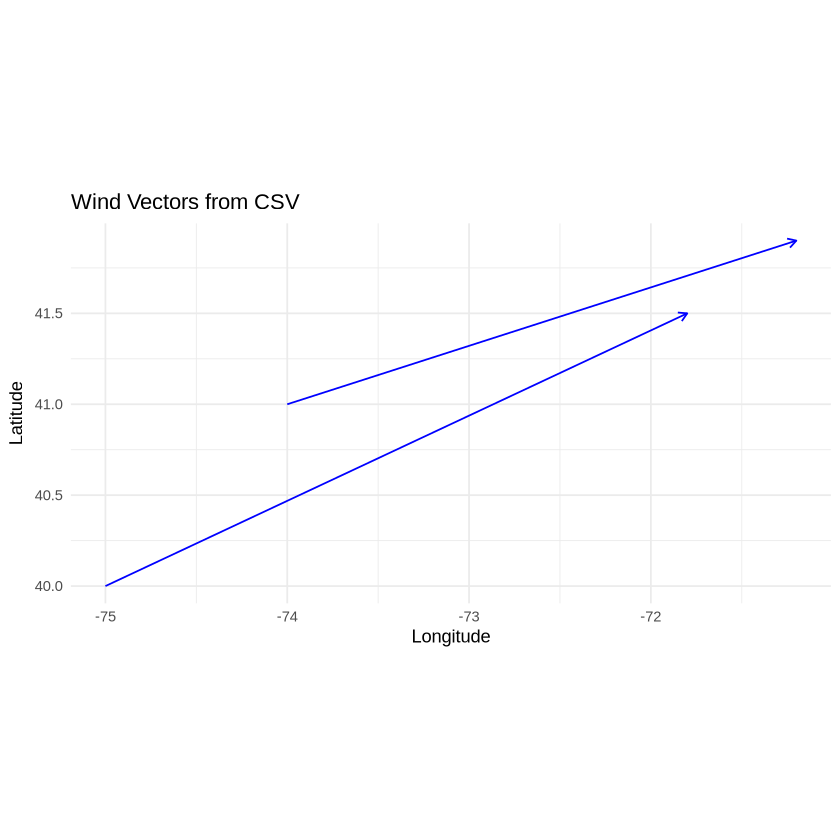

In [5]:
# Load required packages
library(ggplot2)
library(dplyr)

# Read CSV file
# Example CSV structure:
wind_data <- rbind(c(-75,40,3.2,1.5), c(-74,41,2.8,0.9)) %>% as.data.frame
colnames(wind_data) <- c("lon","lat","u","v")
wind_data %>% head
# wind_data <- read.csv("wind_vectors.csv", stringsAsFactors = FALSE)

# Validate data
if (!all(c("lon", "lat", "u", "v") %in% names(wind_data))) {
  stop("CSV must contain columns: lon, lat, u, v")
}

# Quick plot of wind vectors
ggplot(wind_data, aes(x = lon, y = lat)) +
  geom_segment(aes(xend = lon + u, yend = lat + v),
               arrow = arrow(length = unit(0.2, "cm")),
               color = "blue") +
  coord_fixed() +
  theme_minimal() +
  labs(title = "Wind Vectors from CSV",
       x = "Longitude", y = "Latitude")


In [10]:
# ==============================================================================
# WIND FILENAMES + URLS
# ==============================================================================
windspeed.urls <- c("https://downloads.psl.noaa.gov/Datasets/ncep.reanalysis/Monthlies/surface/wspd.mon.mean.nc",
                   "https://downloads.psl.noaa.gov/Datasets/ncep.reanalysis/Monthlies/surface/wspd.sig995.mon.1981-2010.ltm.nc",
                   "https://downloads.psl.noaa.gov/Datasets/ncep.reanalysis/Monthlies/surface/wspd.sig995.mon.ltm.1991-2020.nc")

windspeed.files <- c("wspd.mon.mean.nc",
                     "wspd.sig995.mon.ltm.1981-2010.nc",
                     "wspd.sig995.mon.ltm.1991-2020.nc")


vwind.urls <- c("https://downloads.psl.noaa.gov/Datasets/ncep.reanalysis/Monthlies/surface/vwnd.sig995.mon.mean.nc",
                "https://downloads.psl.noaa.gov/Datasets/ncep.reanalysis/Monthlies/surface/vwnd.sig995.day.ltm.1981-2010.nc",
                "https://downloads.psl.noaa.gov/Datasets/ncep.reanalysis/Monthlies/surface/vwnd.sig995.day.ltm.1991-2020.nc")

vwind.files <- c("vwnd.sig995.mon.mean.nc",
                 "vwnd.sig995.day.ltm.1981-2010.nc",
                 "vwnd.sig995.day.ltm.1991-2020.nc")


uwind.urls <- c("https://downloads.psl.noaa.gov/Datasets/ncep.reanalysis/Monthlies/surface/uwnd.sig995.mon.mean.nc",
                "https://downloads.psl.noaa.gov/Datasets/ncep.reanalysis/Monthlies/surface/uwnd.sig995.mon.ltm.1981-2010.nc",
                "https://downloads.psl.noaa.gov/Datasets/ncep.reanalysis/Monthlies/surface/uwnd.sig995.mon.ltm.1991-2020.nc")

uwind.files <- c("uwnd.sig995.mon.mean.nc",
                 "uwnd.sig995.day.ltm.1981-2010.nc",
                 "uwnd.sig995.day.ltm.1991-2020.nc")


In [14]:
download.filename(windspeed.files[1], windspeed.urls[1]) ; windspeed <- move.file(windspeed.files[1], dataDir)
download.filename(vwind.files[1], vwind.urls[1]) ; vwind <- move.file(vwind.files[1], dataDir)
download.filename(uwind.files[1], uwind.urls[1]) ; uwind <- move.file(uwind.files[1], dataDir)


[1] "File Downloaded"
[1] "File Downloaded"
[1] "File Downloaded"


In [25]:
nc <- nc_open(uwind)
print(nc)
nc_close(nc)

File /data/jwd07/pulsar_staging/108113781/working/jupyter/Data/uwnd.sig995.mon.mean.nc (NC_FORMAT_NETCDF4_CLASSIC):

     1 variables (excluding dimension variables):
        float uwnd[lon,lat,time]   (Chunking: [144,73,1])  (Compression: shuffle,level 2)
            long_name: Monthly Mean Zonal Wind at sigma level 0.995
            valid_range: -102.199996948242
             valid_range: 102.199996948242
            units: m/s
            add_offset: 0
            scale_factor: 1
            missing_value: -9.96920996838687e+36
            precision: 2
            least_significant_digit: 1
            var_desc: u-wind
            statistic: Mean
            parent_stat: Other
            dataset: NCEP Reanalysis Derived Products
            level_desc: 0.995 sigma
            actual_range: -18.8393516540527
             actual_range: 18.8058052062988

     3 dimensions:
        lat  Size:73 
            units: degrees_north
            actual_range: 90
             actual_range: -9

Warning message:
“[rast] unknown extent”
Warning message:
“[rast] unknown extent”
Warning message:
“[rast] unknown extent”


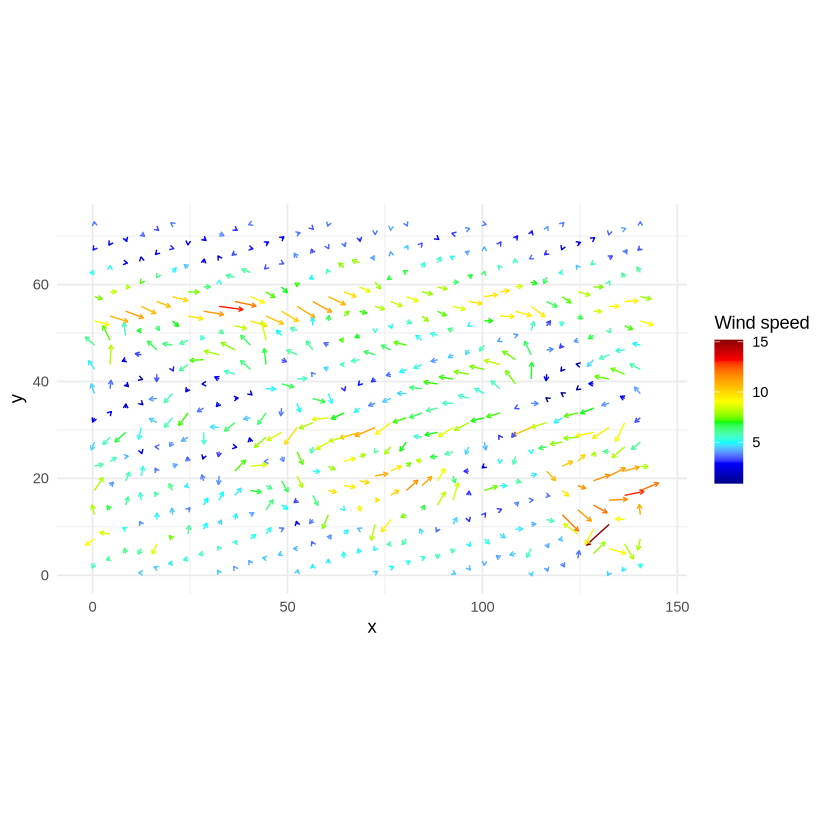

In [49]:
# Load NetCDF files
u <- rast(uwind)
v <- rast(vwind)
speed <- rast(windspeed)  # optional (can compute instead)

# If needed: compute speed yourself
# speed <- sqrt(u^2 + v^2)

# Convert to dataframe
df_u <- as.data.frame(u, xy = TRUE)
df_v <- as.data.frame(v, xy = TRUE)
df_s <- as.data.frame(speed, xy = TRUE)

# Merge all
df <- df_u %>%
  rename(u = 3) %>%
  left_join(df_v %>% rename(v = 3), by = c("x", "y")) %>%
  left_join(df_s %>% rename(speed = 3), by = c("x", "y"))

# Optional: thin arrows (important for readability)
df_arrow <- df %>% 
  slice(seq(1, n(), by = 20))

colors <- length(unique(speed))
# Plot
ggplot(df_arrow) +
  geom_segment(aes(x = x, y = y,
                   xend = x + u * 0.5,
                   yend = y + v * 0.5,
                   color = speed),
               arrow = arrow(length = unit(0.1, "cm")),
               size = 0.4) +

  scale_color_gradientn(
    colours = c("dark blue", "blue", "cyan", "green", "yellow", "orange", "red", "dark red"),
    name = "Wind speed"
  ) +
  coord_quickmap() +
  theme_minimal()

Warning message:
“[rast] unknown extent”
Warning message:
“[rast] unknown extent”
Warning message:
“[rast] unknown extent”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


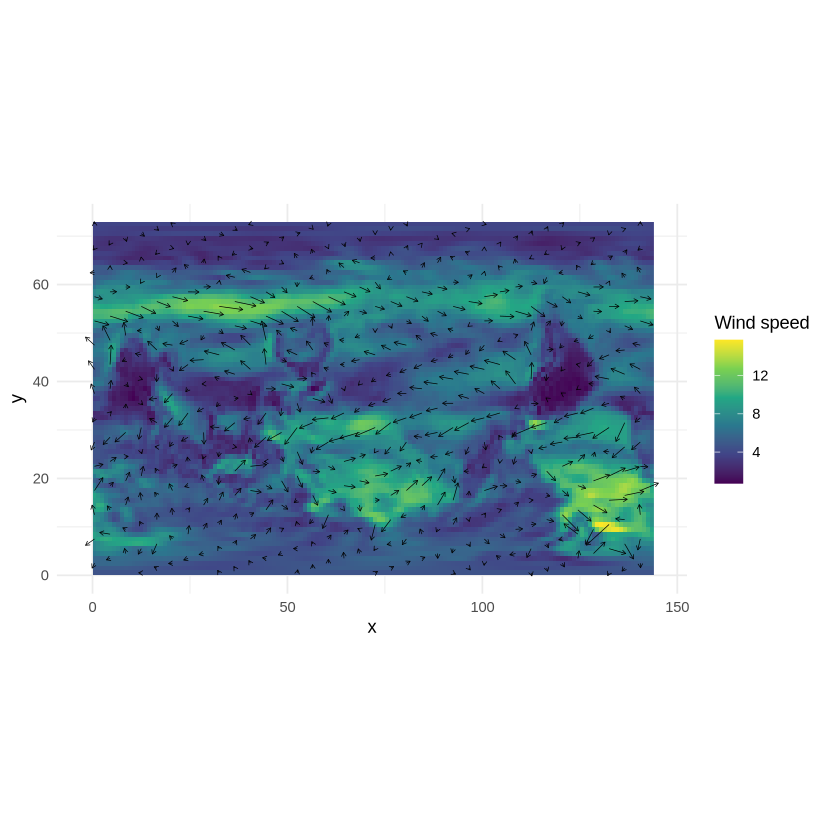

In [24]:
# Convert to dataframe
df_u <- as.data.frame(u, xy = TRUE)
df_v <- as.data.frame(v, xy = TRUE)
df_s <- as.data.frame(speed, xy = TRUE)

In [27]:
df_u %>% head()
df_v %>% head()
df_s %>% head()

df %>% head()


,x,y,uwnd.sig995.mon.mean_1,uwnd.sig995.mon.mean_2,uwnd.sig995.mon.mean_3,uwnd.sig995.mon.mean_4,uwnd.sig995.mon.mean_5,uwnd.sig995.mon.mean_6,uwnd.sig995.mon.mean_7,uwnd.sig995.mon.mean_8,⋯,uwnd.sig995.mon.mean_929,uwnd.sig995.mon.mean_930,uwnd.sig995.mon.mean_931,uwnd.sig995.mon.mean_932,uwnd.sig995.mon.mean_933,uwnd.sig995.mon.mean_934,uwnd.sig995.mon.mean_935,uwnd.sig995.mon.mean_936,uwnd.sig995.mon.mean_937,uwnd.sig995.mon.mean_938
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.5,72.5,-0.1329001,-1.593792,-6.826449,-4.441665,-3.952256,-5.717999,-3.972257,-6.271609,⋯,-3.520160,-4.088333,-2.834677,-2.656451,-3.882499,-3.003224,-1.1966656,-0.26774114,-9.96921e+36,-9.96921e+36
2,1.5,72.5,-0.1787085,-1.571379,-6.789998,-4.379997,-3.842580,-5.667331,-3.821610,-6.203869,⋯,-3.454031,-3.942499,-2.651612,-2.425806,-3.731666,-2.749193,-1.0674990,-0.16612831,-9.96921e+36,-9.96921e+36
3,2.5,72.5,-0.2212889,-1.549998,-6.742580,-4.320333,-3.730644,-5.606665,-3.672579,-6.129353,⋯,-3.374192,-3.798333,-2.459677,-2.189515,-3.579166,-2.495160,-0.9374989,-0.06209598,-9.96921e+36,-9.96921e+36
4,3.5,72.5,-0.2599994,-1.527929,-6.673546,-4.252332,-3.610000,-5.529332,-3.508384,-6.048709,⋯,-3.302419,-3.644166,-2.269354,-1.946773,-3.417499,-2.233870,-0.8049990,0.03871040,-9.96921e+36,-9.96921e+36
5,4.5,72.5,-0.3022559,-1.499653,-6.597095,-4.169998,-3.482579,-5.450999,-3.344192,-5.953869,⋯,-3.216934,-3.486666,-2.066934,-1.705644,-3.250832,-1.978225,-0.6658324,0.13951693,-9.96921e+36,-9.96921e+36
6,5.5,72.5,-0.3441915,-1.469998,-6.505803,-4.085331,-3.347741,-5.351998,-3.163545,-5.844513,⋯,-3.122580,-3.317499,-1.872579,-1.454031,-3.072499,-1.711289,-0.5383323,0.24354909,-9.96921e+36,-9.96921e+36


,x,y,vwnd.sig995.mon.mean_1,vwnd.sig995.mon.mean_2,vwnd.sig995.mon.mean_3,vwnd.sig995.mon.mean_4,vwnd.sig995.mon.mean_5,vwnd.sig995.mon.mean_6,vwnd.sig995.mon.mean_7,vwnd.sig995.mon.mean_8,⋯,vwnd.sig995.mon.mean_929,vwnd.sig995.mon.mean_930,vwnd.sig995.mon.mean_931,vwnd.sig995.mon.mean_932,vwnd.sig995.mon.mean_933,vwnd.sig995.mon.mean_934,vwnd.sig995.mon.mean_935,vwnd.sig995.mon.mean_936,vwnd.sig995.mon.mean_937,vwnd.sig995.mon.mean_938
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.5,72.5,0.9561315,-0.3965501,-0.7303225,-1.157331,-2.348709,-1.053997,-3.260967,-1.267095,⋯,-1.457257,-3.091666,-4.134676,-5.268547,-3.304166,-5.621773,-2.936666,-2.317741,-2.241934,-2.408927
2,1.5,72.5,0.9583898,-0.4606870,-1.0299983,-1.348333,-2.519033,-1.302332,-3.434837,-1.537741,⋯,-1.608063,-3.269999,-4.257258,-5.379031,-3.471665,-5.747580,-2.985832,-2.328224,-2.257257,-2.591963
3,2.5,72.5,0.9467763,-0.5262046,-1.3216115,-1.540666,-2.686774,-1.551999,-3.597741,-1.807096,⋯,-1.762096,-3.438333,-4.369354,-5.479837,-3.630832,-5.861290,-3.024166,-2.329837,-2.267741,-2.766070
4,3.5,72.5,0.9354848,-0.6006875,-1.6187080,-1.726666,-2.847740,-1.791999,-3.760967,-2.070965,⋯,-1.908870,-3.597499,-4.473386,-5.564515,-3.778332,-5.966128,-3.069999,-2.334676,-2.277418,-2.933928
5,4.5,72.5,0.9219350,-0.6689632,-1.8993530,-1.909666,-3.001935,-2.031000,-3.906772,-2.333225,⋯,-2.045967,-3.759166,-4.563709,-5.647579,-3.931666,-6.061290,-3.096666,-2.323386,-2.280644,-3.097320
6,5.5,72.5,0.9100002,-0.7286198,-2.1825793,-2.088665,-3.150968,-2.261997,-4.047740,-2.593226,⋯,-2.181450,-3.905832,-4.649192,-5.716127,-4.072498,-6.133870,-3.119165,-2.320160,-2.279031,-3.257142


,x,y,wspd.mon.mean_1,wspd.mon.mean_2,wspd.mon.mean_3,wspd.mon.mean_4,wspd.mon.mean_5,wspd.mon.mean_6,wspd.mon.mean_7,wspd.mon.mean_8,⋯,wspd.mon.mean_929,wspd.mon.mean_930,wspd.mon.mean_931,wspd.mon.mean_932,wspd.mon.mean_933,wspd.mon.mean_934,wspd.mon.mean_935,wspd.mon.mean_936,wspd.mon.mean_937,wspd.mon.mean_938
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.5,72.5,3.779999,4.819992,8.220001,6.119995,7,6.330002,5.729996,7.130005,⋯,6.234892,6.171464,7.254063,7.714543,6.174839,7.375161,4.625874,4.006455,-9.96921e+36,-9.96921e+36
2,1.5,72.5,3.779999,4.809998,8.220001,6.110001,7,6.330002,5.720001,7.130005,⋯,6.230989,6.169377,7.253572,7.712050,6.176055,7.371066,4.626749,4.008501,-9.96921e+36,-9.96921e+36
3,2.5,72.5,3.779999,4.809998,8.229996,6.110001,7,6.330002,5.729996,7.130005,⋯,6.234610,6.172128,7.254447,7.712347,6.175956,7.375129,4.621859,4.004881,-9.96921e+36,-9.96921e+36
4,3.5,72.5,3.779999,4.819992,8.220001,6.119995,7,6.330002,5.729996,7.130005,⋯,6.240191,6.169645,7.258896,7.708751,6.172687,7.375583,4.627841,4.003764,-9.96921e+36,-9.96921e+36
5,4.5,72.5,3.779999,4.819992,8.220001,6.110001,7,6.330002,5.729996,7.130005,⋯,6.235841,6.173353,7.250112,7.710831,6.180117,7.378908,4.620069,4.002310,-9.96921e+36,-9.96921e+36
6,5.5,72.5,3.779999,4.819992,8.220001,6.110001,7,6.319992,5.729996,7.130005,⋯,6.235581,6.172447,7.254913,7.709325,6.178241,7.372875,4.619067,4.004122,-9.96921e+36,-9.96921e+36


,x,y,u,uwnd.sig995.mon.mean_2,uwnd.sig995.mon.mean_3,uwnd.sig995.mon.mean_4,uwnd.sig995.mon.mean_5,uwnd.sig995.mon.mean_6,uwnd.sig995.mon.mean_7,uwnd.sig995.mon.mean_8,⋯,wspd.mon.mean_929,wspd.mon.mean_930,wspd.mon.mean_931,wspd.mon.mean_932,wspd.mon.mean_933,wspd.mon.mean_934,wspd.mon.mean_935,wspd.mon.mean_936,wspd.mon.mean_937,wspd.mon.mean_938
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.5,72.5,-0.1329001,-1.593792,-6.826449,-4.441665,-3.952256,-5.717999,-3.972257,-6.271609,⋯,6.234892,6.171464,7.254063,7.714543,6.174839,7.375161,4.625874,4.006455,-9.96921e+36,-9.96921e+36
2,1.5,72.5,-0.1787085,-1.571379,-6.789998,-4.379997,-3.842580,-5.667331,-3.821610,-6.203869,⋯,6.230989,6.169377,7.253572,7.712050,6.176055,7.371066,4.626749,4.008501,-9.96921e+36,-9.96921e+36
3,2.5,72.5,-0.2212889,-1.549998,-6.742580,-4.320333,-3.730644,-5.606665,-3.672579,-6.129353,⋯,6.234610,6.172128,7.254447,7.712347,6.175956,7.375129,4.621859,4.004881,-9.96921e+36,-9.96921e+36
4,3.5,72.5,-0.2599994,-1.527929,-6.673546,-4.252332,-3.610000,-5.529332,-3.508384,-6.048709,⋯,6.240191,6.169645,7.258896,7.708751,6.172687,7.375583,4.627841,4.003764,-9.96921e+36,-9.96921e+36
5,4.5,72.5,-0.3022559,-1.499653,-6.597095,-4.169998,-3.482579,-5.450999,-3.344192,-5.953869,⋯,6.235841,6.173353,7.250112,7.710831,6.180117,7.378908,4.620069,4.002310,-9.96921e+36,-9.96921e+36
6,5.5,72.5,-0.3441915,-1.469998,-6.505803,-4.085331,-3.347741,-5.351998,-3.163545,-5.844513,⋯,6.235581,6.172447,7.254913,7.709325,6.178241,7.372875,4.619067,4.004122,-9.96921e+36,-9.96921e+36


In [6]:
library(ncdf4)

# Open NetCDF file

nc <- nc_open(windspeed)

# Read variables (names depend on your dataset)
lon <- ncvar_get(nc, "lon")
lat <- ncvar_get(nc, "lat")
u <- ncvar_get(nc, "u10")  # U-component at 10m
v <- ncvar_get(nc, "v10")  # V-component at 10m

nc_close(nc)

# Flatten into a data frame
wind_df <- expand.grid(lon = lon, lat = lat)
wind_df$u <- as.vector(u)
wind_df$v <- as.vector(v)

# Plot
library(ggplot2)
ggplot(wind_df, aes(x = lon, y = lat)) +
  geom_segment(aes(xend = lon + u, yend = lat + v),
               arrow = arrow(length = unit(0.15, "cm")),
               color = "red") +
  coord_fixed() +
  theme_minimal() +
  labs(title = "Wind Vectors from NetCDF",
       x = "Longitude", y = "Latitude")


Error in R_nc4_open: No such file or directory


ERROR: Error in nc_open("wind_data.nc"): Error in nc_open trying to open file wind_data.nc (return_on_error= FALSE )


In [ ]:
wind_df$speed <- sqrt(wind_df$u^2 + wind_df$v^2)
wind_df$direction <- (atan2(wind_df$u, wind_df$v) * 180 / pi + 360) %% 360


https://psl.noaa.gov/data/gridded/data.ncep.reanalysis.html
* 

https://www.ncei.noaa.gov/products/international-comprehensive-ocean-atmosphere-data-set
* https://www.ncei.noaa.gov/data/international-comprehensive-ocean-atmosphere/v3/archive/nrt/monthly/


In [ ]:
# Load required libraries
library(ncdf4)         # To read netCDF files
library(ggplot2)       # For plotting
library(viridis)       # For color scales in the plot
library(sf)            # For handling spatial objects
library(rnaturalearth) # For retrieving coastline data
library(rnaturalearthdata)

In [ ]:
# Defined locations
netcdf_file <- "path/to/your/file.nc"       # Full path to the netCDF file
output_dir  <- "path/to/your/directory/"   # Output directory to save the map

In [ ]:
# Names of variables in the netCDF file (modify according to your file)
var_lon <- "longitude"  # Variable name for longitude
var_lat <- "latitude"   # Variable name for latitude
var_u   <- "uo"         # Variable name for the u component of current
var_v   <- "vo"         # Variable name for the v component of current

In [ ]:
# Open the netCDF file
nc_data <- nc_open(netcdf_file)

# Extract the data (variable names and dimensions may vary)
lon <- ncvar_get(nc_data, var_lon)
lat <- ncvar_get(nc_data, var_lat)
u   <- ncvar_get(nc_data, var_u)
v   <- ncvar_get(nc_data, var_v)

# Close the netCDF file
nc_close(nc_data)

In [ ]:
# Verify that dimensions match (assuming a grid of lon x lat)
if (length(lon) * length(lat) != length(u)) {
  stop("Variable dimensions do not match. Check your netCDF file.")
}

In [ ]:
# Create a grid with all combinations of lon and lat
grid <- expand.grid(lon = lon, lat = lat)

In [ ]:
# Assign the u and v values to the grid (convert to vectors)
grid$u <- as.vector(u)
grid$v <- as.vector(v)
grid$speed <- sqrt(grid$u^2 + grid$v^2)  # Calculate current speed

# Adjust 'skip' to modify the number of arrows plotted
skip <- 10
grid_subset <- grid[seq(1, nrow(grid), by = skip), ]

# Determine geographic extent for plotting
min_lon <- min(grid$lon, na.rm = TRUE)
max_lon <- max(grid$lon, na.rm = TRUE)
min_lat <- min(grid$lat, na.rm = TRUE)
max_lat <- max(grid$lat, na.rm = TRUE)

In [ ]:
## ---- Loading Coastline Data ----
# Load coastline data using rnaturalearth
world <- ne_countries(scale = "medium", returnclass = "sf")

In [ ]:
p <- ggplot() +
  geom_sf(data = world, fill = NA, color = "black", linewidth = 0.5) +
  geom_segment(
    data = grid_subset,
    aes(x = lon, y = lat, xend = lon + u, yend = lat + v, color = speed),
    # Adjust arrow size by modifying the length (e.g., unit(0.15, "cm") to another value)
    arrow = arrow(length = unit(0.15, "cm")),
    # Adjust arrow thickness by changing 'linewidth'
    linewidth = 0.5
  ) +
  # Change the color gradient by modifying the 'option' parameter in scale_color_viridis (e.g., "magma", "inferno", etc.)\n  scale_color_viridis(option = "plasma") +
  coord_sf(xlim = c(min_lon, max_lon), ylim = c(min_lat, max_lat), expand = FALSE) +
  theme_minimal() +
  labs(
    title = "Ocean Current Vectors (Subset)",  # Modify the title as needed
    x = "Longitude",
    y = "Latitude",
    color = "Speed (m/s)"
  )

print(p)

In [ ]:
output_file <- file.path(output_dir, "ocean_current_vectors.png")
ggsave(output_file, p, width = 15, height = 12, dpi = 300)